# Lotto Statistical Analysis
## 1. Title, Scope, and Research Questions

### Phases 1–3: cleaning, exploratory diagnostics, and Monte Carlo baseline

This executable notebook documents canonical data cleaning, Phase 2 descriptive and preliminary statistical diagnostics, and the completed Phase 3 random baseline.

**Scope:** 3D Lotto 9PM and Lotto 6/42. Historical observations are not number recommendations. Prediction and JEV are disabled; this notebook makes no model calls.

**Research questions**
- Do cleaned histories and derived Phase 2 features agree structurally?
- How do observed frequencies, repetition, sums, and consecutive-draw behavior compare with fair-process expectations?
- Are those diagnostics unusual relative to the approved seeded Monte Carlo baselines?


## 2. Reproducibility and Environment

**Analytical question:** Can the canonical analysis be repeated in a clean Python kernel?
**Method and rationale:** Use the project’s installed NumPy, pandas, and Matplotlib stack, load repository artifacts by relative path, and replay the existing Phase 3 implementation with its recorded seed and substreams.
**Limitation:** Exact replay depends on the recorded NumPy behavior and the unchanged Phase 3 implementation.


In [1]:
from pathlib import Path
from collections import Counter
import hashlib
import importlib.util
import json
import math
import subprocess
import sys

sys.dont_write_bytecode = True
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
assert (ROOT / 'monte_carlo_baseline.py').is_file(), f'Open this notebook with the repository as its working directory: {ROOT}'
plt.rcParams.update({'figure.figsize': (10, 4.8), 'axes.grid': True, 'grid.alpha': 0.22, 'font.size': 10})

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

def git(*args):
    result = subprocess.run(['git', *args], cwd=ROOT, capture_output=True, text=True, check=False)
    if result.returncode:
        raise RuntimeError(f'Git command failed: git {args}')
    return result.stdout.strip()

phase3_path = ROOT / 'phase3_monte_carlo_results.json'
phase3 = json.loads(phase3_path.read_text(encoding='utf-8'))
phase2_report = (ROOT / 'phase2_randomness_diagnostics.md').read_text(encoding='utf-8')
cleaning_report = (ROOT / 'lotto_data_cleaning_report.md').read_text(encoding='utf-8')

module_spec = importlib.util.spec_from_file_location('lotto_phase3_baseline', ROOT / 'monte_carlo_baseline.py')
mc = importlib.util.module_from_spec(module_spec)
module_spec.loader.exec_module(mc)

environment = pd.DataFrame([
    {'Component': 'Python', 'Version': sys.version.split()[0]},
    {'Component': 'NumPy', 'Version': np.__version__},
    {'Component': 'pandas', 'Version': pd.__version__},
    {'Component': 'Matplotlib', 'Version': plt.matplotlib.__version__},
])
display(environment)


,Component,Version
0,Python,3.12.10
1,NumPy,2.5.3
2,pandas,3.0.6
3,Matplotlib,3.11.2


## 3. Data Sources and Provenance

**Question:** Which canonical files support the reported Phase 2 and Phase 3 results?
The manifest below is loaded from the Phase 3 JSON, which records each canonical Phase 2 input’s row count and SHA-256. Cleaning outputs and reports are also checked in the next section. Published draw order remains in source columns for audit; the experiments use unordered outcomes as defined below.


In [2]:
manifest_rows = []
for key, record in phase3['inputs'].items():
    manifest_rows.append({
        'Phase 3 input key': key,
        'Repository file': Path(record['path']).name,
        'Rows': record['rows'],
        'SHA-256': record['sha256'],
    })
display(pd.DataFrame(manifest_rows))


,Phase 3 input key,Repository file,Rows,SHA-256
0,3d_analysis_ready,swertres_9pm_analysis_ready.csv,3718.0,bed32547054a819e108f18d53af73db1f74db693202db0...
1,3d_digit_frequency,swertres_9pm_digit_frequency.csv,10.0,4ad90a87cbaaca99a08001904b7bbef18e1561ed4b9c5a...
2,3d_phase2,swertres_9pm_phase2_analysis.csv,3718.0,3b207b356349c0bf4e1677979c1077bea434071508e3f8...
3,6_42_cleaned,lotto_6_42_cleaned_normalized.csv,1605.0,980386a399077564d25de3a3a19aa3611969899895b9e3...
4,6_42_number_frequency,lotto_6_42_number_frequency.csv,42.0,1284586aaccc86f43da2e9676f425842dbf171dde36d8d...
5,6_42_phase2,lotto_6_42_phase2_analysis.csv,1605.0,a7ff6ac667ab9a4dd83c821ca6a7ad94b2866ab15299f5...
6,phase2_report,phase2_randomness_diagnostics.md,NaN,c6318f74cc5685108f4bb278d6293b84771e0c29af7250...


## 4. Data Verification Summary

**Question:** Are required canonical datasets and reports present and structurally consistent?
**Method:** Verify Git branch/HEAD and secret-file metadata without opening the secret file; check every required artifact, Phase 3 input hash, schema, chronology, row count, and the Phase 3 validation record.
**Limitation:** Hash agreement establishes file identity with the Phase 3 manifest, not the correctness of the original published lottery records.


In [3]:
required_files = [
    'swertres_9pm_analysis_ready.csv',
    'swertres_9pm_phase2_analysis.csv',
    'swertres_9pm_digit_frequency.csv',
    'swertres_9pm_cleaned_normalized.csv',
    'lotto_6_42_cleaned_normalized.csv',
    'lotto_6_42_phase2_analysis.csv',
    'lotto_6_42_number_frequency.csv',
    'lotto_data_cleaning_report.md',
    'phase2_randomness_diagnostics.md',
    'monte_carlo_baseline.py',
    'phase3_monte_carlo_results.json',
    'phase3_monte_carlo_random_baseline.md',
    'phase3_simulation_distributions.csv',
]
missing_files = [name for name in required_files if not (ROOT / name).is_file()]
assert not missing_files, f'Missing canonical artifacts: {missing_files}'

branch = git('branch', '--show-current')
head = git('rev-parse', 'HEAD')
assert branch == phase3['repository']['branch']
assert head == phase3['repository']['head']

ignored_status = subprocess.run(['git', 'check-ignore', '-q', '--', 'Keys.env'], cwd=ROOT, check=False).returncode == 0
tracked_status = subprocess.run(['git', 'ls-files', '--error-unmatch', '--', 'Keys.env'], cwd=ROOT, capture_output=True, text=True, check=False).returncode == 0
assert ignored_status and not tracked_status
assert phase3['repository']['keys_env_contents_read'] is False
assert phase3['validation']['keys_env_ignored'] is True
assert phase3['validation']['keys_env_untracked'] is True
assert phase3['validation']['keys_env_contents_read'] is False
assert phase3['validation']['jev_or_typesafe_called'] is False

tables = {Path(name).stem: pd.read_csv(ROOT / name) for name in required_files if name.endswith('.csv')}
d3_clean = tables['swertres_9pm_cleaned_normalized']
d3 = tables['swertres_9pm_analysis_ready']
d3p = tables['swertres_9pm_phase2_analysis']
freq3 = tables['swertres_9pm_digit_frequency']
d6 = tables['lotto_6_42_cleaned_normalized']
d6p = tables['lotto_6_42_phase2_analysis']
freq6 = tables['lotto_6_42_number_frequency']
phase3_distributions = tables['phase3_simulation_distributions']

assert len(d3_clean) == 3723 and len(d3) == len(d3p) == 3718
assert len(d3_clean.loc[d3_clean['record_status'] == 'valid']) == 3718
assert len(d3_clean.loc[d3_clean['record_status'] == 'missing_combination']) == 5
assert len(d6) == len(d6p) == 1605
assert len(freq3) == 10 and set(freq3['digit'].astype(int)) == set(range(10))
assert len(freq6) == 42 and set(freq6['number'].astype(int)) == set(range(1, 43))
assert phase3['verdict'] == 'PHASE3_PASS_RANDOM_COMPATIBLE'
assert phase3['validation']['canonical_input_structure'] == 'PASS'
assert phase3['validation']['phase2_feature_consistency'] == 'PASS'
assert phase3['validation']['simulation_domain_and_history_length_checks'] == 'PASS'
assert phase3['configuration']['random_seed'] == 162
assert phase3['configuration']['initial_simulations_per_game'] == 10000
assert phase3['configuration']['confirmation_simulations'] == 100000
assert phase3['configuration']['anomaly_threshold'] == 0.01
assert phase3['configuration']['prediction_enabled'] is False
assert phase3['configuration']['jev_enabled'] is False

manifest_file_map = {
    '3d_analysis_ready': 'swertres_9pm_analysis_ready.csv',
    '3d_digit_frequency': 'swertres_9pm_digit_frequency.csv',
    '3d_phase2': 'swertres_9pm_phase2_analysis.csv',
    '6_42_cleaned': 'lotto_6_42_cleaned_normalized.csv',
    '6_42_number_frequency': 'lotto_6_42_number_frequency.csv',
    '6_42_phase2': 'lotto_6_42_phase2_analysis.csv',
    'phase2_report': 'phase2_randomness_diagnostics.md',
}
for key, name in manifest_file_map.items():
    assert sha256_file(ROOT / name) == phase3['inputs'][key]['sha256'], f'Phase 3 manifest hash mismatch: {name}'

assert d3['record_status'].eq('valid').all() and d6['record_status'].eq('valid').all()
assert pd.to_datetime(d3['draw_date']).is_monotonic_increasing
assert pd.to_datetime(d6['draw_date']).is_monotonic_increasing
assert not pd.to_datetime(d3['draw_date']).duplicated().any()
assert not pd.to_datetime(d6['draw_date']).duplicated().any()

canonical_read_files = sorted(set(required_files))
canonical_hashes_before = {name: sha256_file(ROOT / name) for name in canonical_read_files}
structure_summary = pd.DataFrame([
    {'Dataset': '3D cleaned, including missing results', 'Rows': len(d3_clean), 'Date range': f"{d3_clean['draw_date'].min()} to {d3_clean['draw_date'].max()}"},
    {'Dataset': '3D analysis-ready and Phase 2', 'Rows': len(d3), 'Date range': f"{d3['draw_date'].min()} to {d3['draw_date'].max()}"},
    {'Dataset': 'Lotto 6/42 cleaned and Phase 2', 'Rows': len(d6), 'Date range': f"{d6['draw_date'].min()} to {d6['draw_date'].max()}"},
    {'Dataset': 'Phase 3 simulation distributions', 'Rows': len(phase3_distributions), 'Date range': 'Not applicable'},
])
display(structure_summary)
print(f'Git: branch={branch}, HEAD={head}')
print(f'Keys.env ignored={ignored_status}; tracked={tracked_status}; contents opened by this notebook=no')
print(f'Phase 3 verdict={phase3["verdict"]}; canonical structure and feature checks=PASS')
display(Markdown(cleaning_report))


,Dataset,Rows,Date range
0,"3D cleaned, including missing results",3723,2016-01-02 to 2026-10-07
1,3D analysis-ready and Phase 2,3718,2016-01-02 to 2026-10-07
2,Lotto 6/42 cleaned and Phase 2,1605,2016-01-02 to 2026-10-06
3,Phase 3 simulation distributions,16,Not applicable


Git: branch=main, HEAD=7eeca79065d5f3f83ff476dbe377076376ff87e1
Keys.env ignored=True; tracked=False; contents opened by this notebook=no
Phase 3 verdict=PHASE3_PASS_RANDOM_COMPATIBLE; canonical structure and feature checks=PASS


# Lotto Data Cleaning and Normalization Report

## Scope

This cleaning pass covers:

- `swertres9pm.md`
- `6-42.csv`

The raw files were left unchanged. Cleaned outputs were written as separate CSV files.

## Source integrity

| Source | SHA-256 |
|---|---|
| `swertres9pm.md` | `b8c1e1f762c8b3059956d96b344804498bc20bc9f174a358fc616ae115ecb1a3` |
| `6-42.csv` | `9d8bf396373cd20ac197f423ed245407fa701bbd28895b2bb55e1dca92e3e8a8` |

## 3D Lotto 9PM

### Raw audit

- Raw data rows: **3,729**
- Exact duplicate rows removed: **6**
- Cleaned canonical rows: **3,723**
- Valid draw-result rows: **3,718**
- Rows with missing combination (`--`): **5**
- Remaining duplicate draw dates after cleanup: **0**
- Date range: **2016-01-02 to 2026-10-07**

### Transformations

1. Removed only **exact duplicate records**.
2. Converted draw dates from `M/D/YYYY` to ISO `YYYY-MM-DD`.
3. Preserved 3D combinations as text in `x-x-x` form.
4. Split each valid combination into `digit_1`, `digit_2`, and `digit_3`.
5. Standardized game metadata into `lotto_game = 3D Lotto` and `draw_session = 9PM`.
6. Converted jackpot values to numeric decimal text without thousands separators.
7. Converted winners to integers.
8. Preserved rows containing `--` as `missing_combination`; no result was guessed or imputed.
9. Sorted records chronologically.
10. Added `record_status` and `source_row` for auditability.

### Analysis-ready dataset

`swertres_9pm_analysis_ready.csv` contains only rows with a valid three-digit result. Missing-result rows remain in the canonical cleaned file but are excluded from the analysis-ready copy.

## Lotto 6/42

### Raw audit

- Raw data rows: **1,609**
- Exact duplicate rows removed: **4**
- Cleaned canonical rows: **1,605**
- Invalid combination rows after validation: **0**
- Remaining duplicate draw dates after cleanup: **0**
- Date range: **2016-01-02 to 2026-10-06**

### Transformations

1. Removed only **exact duplicate records**.
2. Trimmed whitespace from source column names and values.
3. Converted draw dates from `M/D/YYYY` to ISO `YYYY-MM-DD`.
4. Preserved the published six-number order in `combination_published`.
5. Added `combination_sorted` as a canonical unordered representation for set-based analysis.
6. Split each draw into `number_1` through `number_6`.
7. Validated that every draw has exactly six distinct numbers in the range 1 to 42.
8. Standardized combinations to two-digit text such as `03-07-16-25-31-42`.
9. Removed the `PHP` label and thousands separators from jackpot values while preserving two decimal places.
10. Converted winners to integers.
11. Sorted records chronologically.
12. Added `record_status` and `source_row` for auditability.

## Cleaning boundaries

No missing lottery result was inferred from surrounding draws. No statistical imputation was used. No outlier was removed based on jackpot size, winner count, digit frequency, or number frequency. Those values may be analytically interesting and should remain available for later statistical testing.

The cleaned datasets are suitable for the next stage: descriptive statistics, randomness diagnostics, chronological train/validation/test splitting, Monte Carlo baselines, and later ML/JEV evaluation.


## 5. Experimental Definitions

**Question:** What does a simulated draw represent?
- **3D Lotto:** an unordered three-digit multiset. Repeated digits count with multiplicity; published order is retained only as provenance.
- **Lotto 6/42:** an unordered set of six distinct values from 1 through 42; published order is retained only for audit.
- **Baseline:** independent fair outcomes under each game’s draw rules, with historical sample length preserved.
- **Calibration:** empirical Monte Carlo p-values use the Phase 3 recorded tail rules and the plus-one correction. The 0.01 threshold would trigger a diagnostic-only 100,000-history confirmation.


In [4]:
validated_data, validated_paths = mc.validate_inputs()
draws3_mc = validated_data['3d_lotto']['draws'].astype(np.int64)
draws6_mc = validated_data['lotto_6_42']['draws'].astype(np.int64)
draws3 = d3[[f'digit_{i}' for i in range(1, 4)]].to_numpy(dtype=np.int64)
draws6 = d6[[f'number_{i}' for i in range(1, 7)]].to_numpy(dtype=np.int64)
assert np.array_equal(draws3, draws3_mc)
assert np.array_equal(draws6, draws6_mc)
assert draws3.shape == (3718, 3) and np.all((draws3 >= 0) & (draws3 <= 9))
assert draws6.shape == (1605, 6) and np.all((draws6 >= 1) & (draws6 <= 42))
assert np.all(np.diff(np.sort(draws6, axis=1), axis=1) != 0)

phase2_dates3 = pd.to_datetime(d3p['draw_date']).to_numpy()
phase2_dates6 = pd.to_datetime(d6p['draw_date']).to_numpy()
assert np.array_equal(pd.to_datetime(d3['draw_date']).to_numpy(), phase2_dates3)
assert np.array_equal(pd.to_datetime(d6['draw_date']).to_numpy(), phase2_dates6)

digit_counts = np.bincount(draws3.ravel(), minlength=10)
number_counts = np.bincount(draws6.ravel(), minlength=43)[1:]
assert np.array_equal(
    freq3.sort_values('digit')['observed_count'].to_numpy(dtype=np.int64),
    digit_counts,
)
assert np.array_equal(
    freq6.sort_values('number')['observed_count'].to_numpy(dtype=np.int64),
    number_counts,
)

pattern_unique_counts = np.apply_along_axis(lambda row: len(set(row)), 1, draws3)
pattern_labels = np.select(
    [pattern_unique_counts == 3, pattern_unique_counts == 1],
    ['all_distinct', 'triple'],
    default='one_pair',
)
assert np.array_equal(pattern_labels, d3p['pattern_type'].to_numpy())
digit_sums = draws3.sum(axis=1)
assert np.array_equal(digit_sums, d3p['digit_sum'].to_numpy(dtype=np.int64))
draw_sums = draws6.sum(axis=1)
odd_counts = (draws6 % 2 == 1).sum(axis=1)
assert np.array_equal(draw_sums, d6p['draw_sum'].to_numpy(dtype=np.int64))
assert np.array_equal(odd_counts, d6p['odd_count'].to_numpy(dtype=np.int64))

print('Phase 3 structural validator: PASS')
print('Canonical history arrays, frequency tables, unordered 3D patterns, sums, and 6/42 odd counts: PASS')


Phase 3 structural validator: PASS
Canonical history arrays, frequency tables, unordered 3D patterns, sums, and 6/42 odd counts: PASS


## 6. 3D Lotto Descriptive Analysis

**Analytical question:** Are the pooled counts of digits 0–9 close to equal frequency?
**Method and rationale:** Count all digit positions and compare each count with the fair-process expectation of one tenth of 11,154 observations. The digit-level table and chart display counts without ranking numbers as future candidates.
**Limitation:** Frequency alone does not establish a change in future draw probabilities.


,Draws,Digit observations,Digit-sum mean,Digit-sum sample variance,Digit-sum minimum,Digit-sum maximum
0,3718,11154,13.357181,24.575643,0,27


,Digit,Observed count,Expected count under equal frequency,Observed share (%)
0,0,1154,1115.4,10.346
1,1,1147,1115.4,10.283
2,2,1123,1115.4,10.068
3,3,1095,1115.4,9.817
4,4,1122,1115.4,10.059
5,5,1121,1115.4,10.050
6,6,1091,1115.4,9.781
7,7,1157,1115.4,10.373
8,8,1050,1115.4,9.414
9,9,1094,1115.4,9.808


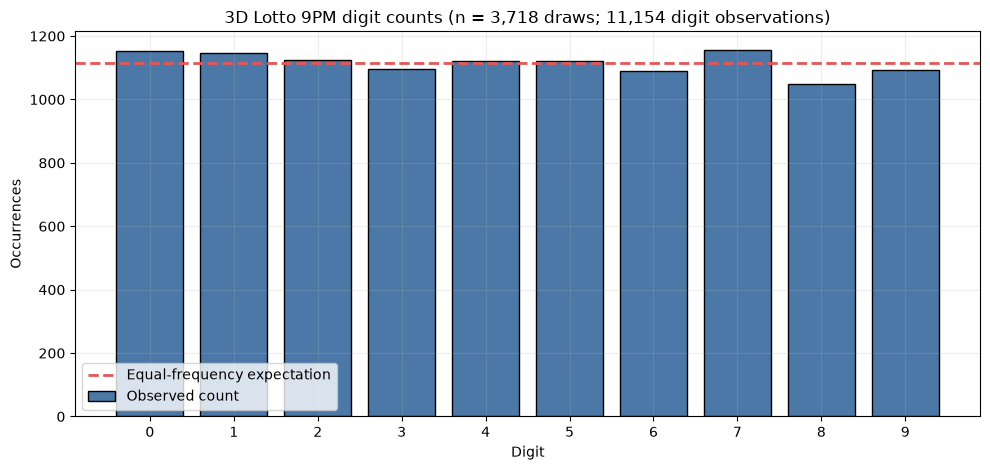

In [5]:
digit_expected = np.full(10, draws3.size / 10)
digit_frequency = pd.DataFrame({
    'Digit': np.arange(10),
    'Observed count': digit_counts,
    'Expected count under equal frequency': digit_expected,
    'Observed share (%)': digit_counts / draws3.size * 100,
})
display(pd.DataFrame([{
    'Draws': len(draws3),
    'Digit observations': draws3.size,
    'Digit-sum mean': digit_sums.mean(),
    'Digit-sum sample variance': digit_sums.var(ddof=1),
    'Digit-sum minimum': digit_sums.min(),
    'Digit-sum maximum': digit_sums.max(),
}]))
display(digit_frequency.round(3))

fig, ax = plt.subplots()
ax.bar(digit_frequency['Digit'], digit_frequency['Observed count'], color='#4c78a8', edgecolor='black', label='Observed count')
ax.axhline(digit_expected[0], color='#e45756', linestyle='--', linewidth=2, label='Equal-frequency expectation')
ax.set(title=f'3D Lotto 9PM digit counts (n = {len(draws3):,} draws; {draws3.size:,} digit observations)', xlabel='Digit', ylabel='Occurrences')
ax.set_xticks(range(10))
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)


## 7. 3D Repetition Patterns

**Analytical question:** Do all-distinct, one-pair, and triple outcomes depart from the probabilities for three independent fair decimal digits?
**Method and rationale:** Compare observed pattern counts with the exact 72%, 27%, and 1% reference proportions, then compute the Pearson diagnostic.
**Limitation:** The nominal chi-square approximation is a preliminary diagnostic; Phase 3 simulation provides the primary calibration.


,Pattern,Observed count,Expected count,Reference probability (%)
0,all_distinct,2644,2676.96,72.0
1,one_pair,1033,1003.86,27.0
2,triple,41,37.18,1.0


Pearson repetition-pattern chi-square = 1.644173; draws = 3718


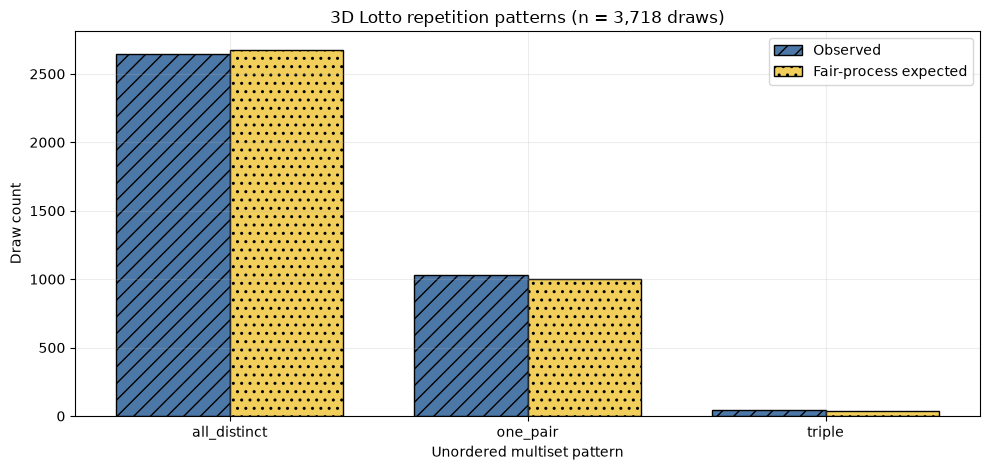

In [6]:
pattern_order = ['all_distinct', 'one_pair', 'triple']
pattern_probabilities = np.array([0.72, 0.27, 0.01])
pattern_counts = np.array([(pattern_labels == label).sum() for label in pattern_order])
pattern_expected = len(draws3) * pattern_probabilities
pattern_table = pd.DataFrame({
    'Pattern': pattern_order,
    'Observed count': pattern_counts,
    'Expected count': pattern_expected,
    'Reference probability (%)': pattern_probabilities * 100,
})
display(pattern_table.round(3))
pattern_chi_square = float(np.sum((pattern_counts - pattern_expected) ** 2 / pattern_expected))
print(f'Pearson repetition-pattern chi-square = {pattern_chi_square:.6f}; draws = {len(draws3)}')

positions = np.arange(len(pattern_order))
width = 0.38
fig, ax = plt.subplots()
ax.bar(positions - width / 2, pattern_counts, width, color='#4c78a8', hatch='//', edgecolor='black', label='Observed')
ax.bar(positions + width / 2, pattern_expected, width, color='#f2cf5b', hatch='..', edgecolor='black', label='Fair-process expected')
ax.set(title=f'3D Lotto repetition patterns (n = {len(draws3):,} draws)', xlabel='Unordered multiset pattern', ylabel='Draw count')
ax.set_xticks(positions, pattern_order)
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)


## 8. 3D Sequential Dependence

**Analytical question:** Do adjacent 3D draws show unusual digit-sum correlation or unordered multiset overlap?
**Method and rationale:** Measure lag-1 correlation of draw sums and count shared digit multiplicities between adjacent draws. Compare overlap categories 0, 1, and 2+ with the exact fair-process reference used by Phase 3.
**Limitation:** These are selected serial diagnostics. They do not cover every possible dependence and do not imply prediction.


Lag-1 digit-sum correlation = -0.003314; transitions = 3717
Mean adjacent unordered multiset overlap = 0.744956; fair expectation = 0.742260


,"Shared digits, with multiplicity",Observed transitions,Fair-process expected transitions
0,0,1468,1458.885
1,1,1755,1776.354
2,2+,494,481.760


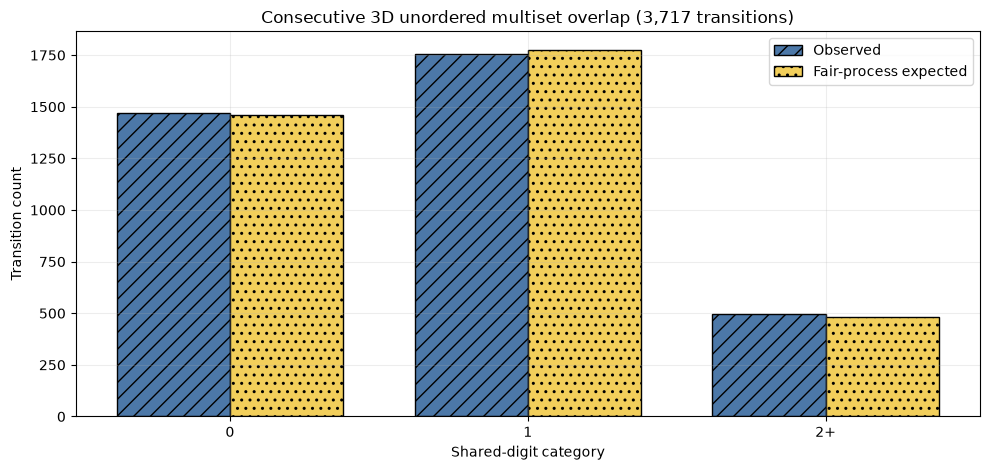

In [7]:
digit_sum_lag1_r = float(np.corrcoef(digit_sums[:-1], digit_sums[1:])[0, 1])
digit_counts_by_draw = np.stack([(draws3 == digit).sum(axis=1) for digit in range(10)], axis=1)
overlaps3 = np.minimum(digit_counts_by_draw[1:], digit_counts_by_draw[:-1]).sum(axis=1)
overlap3_observed = np.array([(overlaps3 == 0).sum(), (overlaps3 == 1).sum(), (overlaps3 >= 2).sum()])
overlap3_probabilities = np.array([
    mc.THREED_OVERLAP_PROBABILITIES[0],
    mc.THREED_OVERLAP_PROBABILITIES[1],
    mc.THREED_OVERLAP_PROBABILITIES[2:].sum(),
])
overlap3_expected = (len(draws3) - 1) * overlap3_probabilities
print(f'Lag-1 digit-sum correlation = {digit_sum_lag1_r:.6f}; transitions = {len(draws3) - 1}')
print(f'Mean adjacent unordered multiset overlap = {overlaps3.mean():.6f}; fair expectation = {np.dot(np.arange(4), mc.THREED_OVERLAP_PROBABILITIES):.6f}')
overlap3_table = pd.DataFrame({
    'Shared digits, with multiplicity': ['0', '1', '2+'],
    'Observed transitions': overlap3_observed,
    'Fair-process expected transitions': overlap3_expected,
})
display(overlap3_table.round(3))

positions = np.arange(3)
width = 0.38
fig, ax = plt.subplots()
ax.bar(positions - width / 2, overlap3_observed, width, color='#4c78a8', hatch='//', edgecolor='black', label='Observed')
ax.bar(positions + width / 2, overlap3_expected, width, color='#f2cf5b', hatch='..', edgecolor='black', label='Fair-process expected')
ax.set(title=f'Consecutive 3D unordered multiset overlap ({len(draws3) - 1:,} transitions)', xlabel='Shared-digit category', ylabel='Transition count')
ax.set_xticks(positions, ['0', '1', '2+'])
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)


## 9. Lotto 6/42 Descriptive Analysis

**Analytical question:** How do historical appearances of numbers 1–42 compare with equal marginal frequency?
**Method and rationale:** Count the six distinct selections in each draw; under a uniform 6-of-42 process, the marginal expected count per number is 6/42 of all selected-number observations.
**Limitation:** Counts within each draw are dependent because selection is without replacement. The nominal Phase 2 test is preliminary; Phase 3 simulates the correct draw mechanism.


,Draws,Selected-number observations,Expected appearances per number,Draw-sum mean,Draw-sum sample variance
0,1605,9630,229.285714,128.576324,771.847818


,Number,Observed count,Expected count under equal marginal frequency,Observed share of draws (%)
0,1,218,229.286,13.583
1,2,226,229.286,14.081
2,3,238,229.286,14.829
3,4,236,229.286,14.704
4,5,243,229.286,15.140
5,6,223,229.286,13.894
6,7,238,229.286,14.829
7,8,234,229.286,14.579
8,9,224,229.286,13.956
9,10,222,229.286,13.832


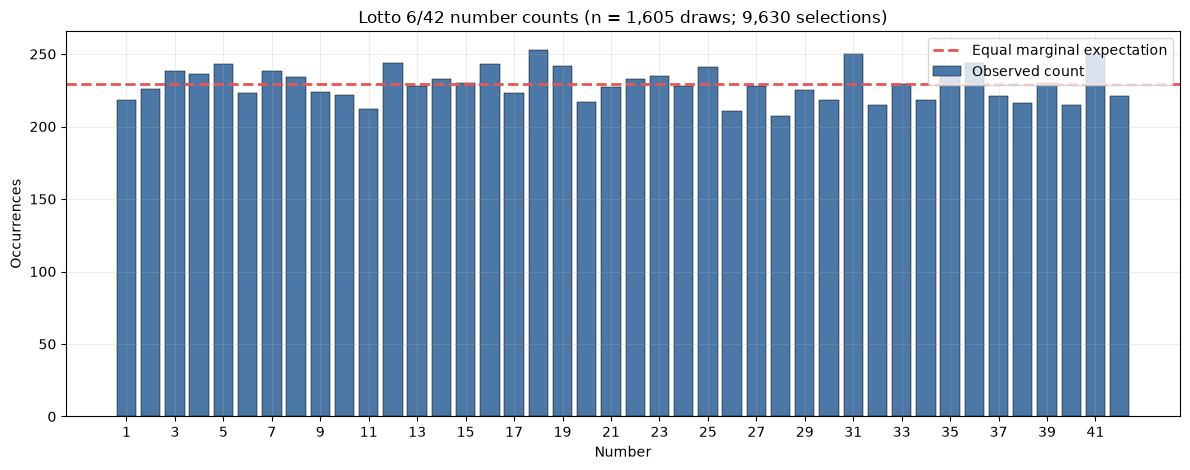

In [8]:
number_expected = np.full(42, len(draws6) * 6 / 42)
number_frequency = pd.DataFrame({
    'Number': np.arange(1, 43),
    'Observed count': number_counts,
    'Expected count under equal marginal frequency': number_expected,
    'Observed share of draws (%)': number_counts / len(draws6) * 100,
})
display(pd.DataFrame([{
    'Draws': len(draws6),
    'Selected-number observations': draws6.size,
    'Expected appearances per number': number_expected[0],
    'Draw-sum mean': draw_sums.mean(),
    'Draw-sum sample variance': draw_sums.var(ddof=1),
}]))
display(number_frequency.round(3))

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.bar(number_frequency['Number'], number_frequency['Observed count'], color='#4c78a8', edgecolor='black', linewidth=0.35, label='Observed count')
ax.axhline(number_expected[0], color='#e45756', linestyle='--', linewidth=2, label='Equal marginal expectation')
ax.set(title=f'Lotto 6/42 number counts (n = {len(draws6):,} draws; {draws6.size:,} selections)', xlabel='Number', ylabel='Occurrences')
ax.set_xticks(np.arange(1, 43, 2))
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)


## 10. Lotto 6/42 Draw Characteristics

**Analytical question:** Are draw sums, odd-number counts, or consecutive-draw overlaps unusual under the fair 6-of-42 model?
**Method and rationale:** Summarize draw sums, compare odd counts with the hypergeometric distribution for 21 odd and 21 even values, and compare shared-number counts with the hypergeometric overlap distribution for two independent 6-of-42 draws.
**Limitation:** Adjacent draws and within-draw numbers are not treated as independent Bernoulli trials; Phase 3 uses without-replacement simulated histories.


,Draws,Draw-sum mean,Draw-sum sample variance,Minimum draw sum,Maximum draw sum,Mean odd count,Mean consecutive overlap,Fair expected consecutive overlap
0,1605,128.576324,771.847818,42,218,3.036137,0.864713,0.857143


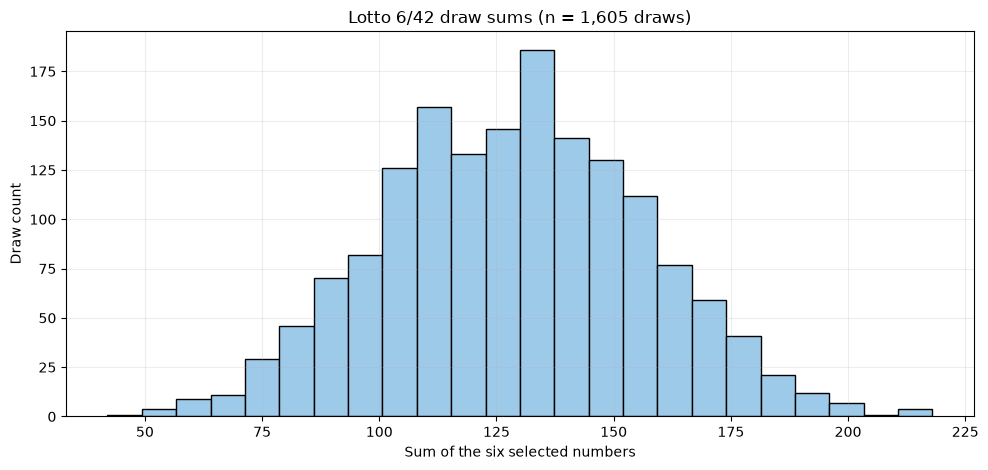

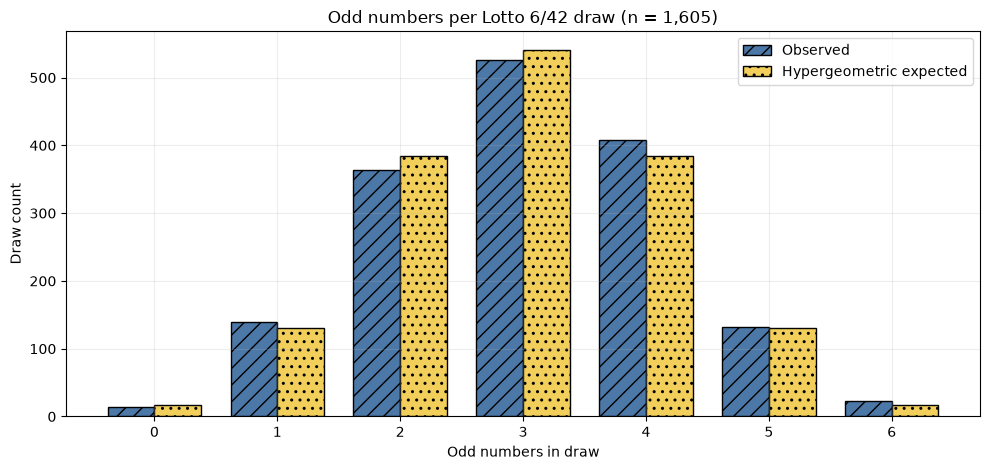

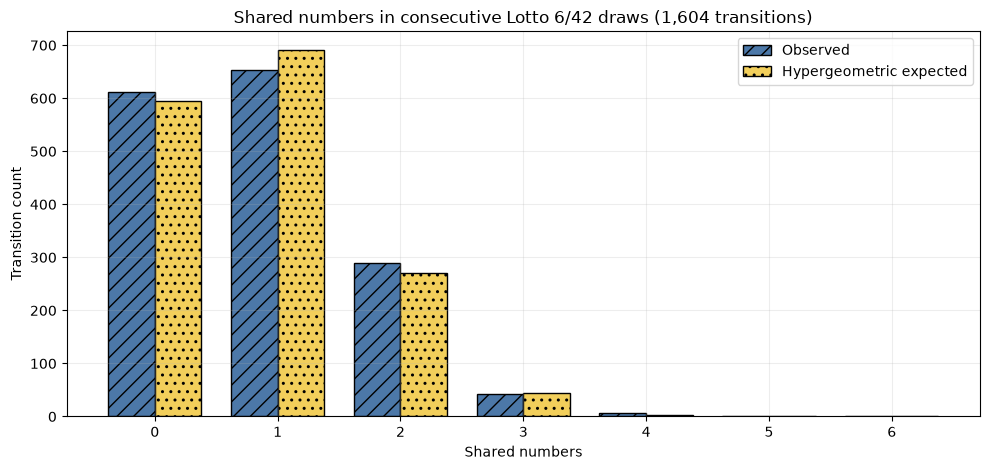

In [9]:
membership6 = (draws6[:, :, None] == np.arange(1, 43)).any(axis=1)
overlaps6 = (membership6[1:] & membership6[:-1]).sum(axis=1)
odd_observed = np.bincount(odd_counts, minlength=7)
odd_expected = len(draws6) * mc.ODD_COUNT_PROBABILITIES
overlap6_observed = np.bincount(overlaps6, minlength=7)
overlap6_expected = (len(draws6) - 1) * mc.LOTTO_OVERLAP_PROBABILITIES

display(pd.DataFrame([{
    'Draws': len(draws6),
    'Draw-sum mean': draw_sums.mean(),
    'Draw-sum sample variance': draw_sums.var(ddof=1),
    'Minimum draw sum': draw_sums.min(),
    'Maximum draw sum': draw_sums.max(),
    'Mean odd count': odd_counts.mean(),
    'Mean consecutive overlap': overlaps6.mean(),
    'Fair expected consecutive overlap': 6 * 6 / 42,
}]))
fig, ax = plt.subplots()
ax.hist(draw_sums, bins=24, color='#9ecae9', edgecolor='black')
ax.set(title=f'Lotto 6/42 draw sums (n = {len(draws6):,} draws)', xlabel='Sum of the six selected numbers', ylabel='Draw count')
fig.tight_layout()
display(fig)
plt.close(fig)

positions = np.arange(7)
width = 0.38
fig, ax = plt.subplots()
ax.bar(positions - width / 2, odd_observed, width, color='#4c78a8', hatch='//', edgecolor='black', label='Observed')
ax.bar(positions + width / 2, odd_expected, width, color='#f2cf5b', hatch='..', edgecolor='black', label='Hypergeometric expected')
ax.set(title=f'Odd numbers per Lotto 6/42 draw (n = {len(draws6):,})', xlabel='Odd numbers in draw', ylabel='Draw count')
ax.set_xticks(positions)
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)

positions = np.arange(7)
fig, ax = plt.subplots()
ax.bar(positions - width / 2, overlap6_observed, width, color='#4c78a8', hatch='//', edgecolor='black', label='Observed')
ax.bar(positions + width / 2, overlap6_expected, width, color='#f2cf5b', hatch='..', edgecolor='black', label='Hypergeometric expected')
ax.set(title=f'Shared numbers in consecutive Lotto 6/42 draws ({len(draws6) - 1:,} transitions)', xlabel='Shared numbers', ylabel='Transition count')
ax.set_xticks(positions)
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)


## 11. Preliminary Statistical Tests

**Question:** What do the Phase 2 nominal Pearson diagnostics report before Monte Carlo calibration?
**Method:** Recompute the three reported chi-square statistics from canonical frequencies and 3D pattern counts. Parse nominal p-values from the canonical Phase 2 report and assert the statistic values agree to the report’s displayed precision.
**Limitation:** A nominal p-value relies on its reference model. In particular, the 6/42 marginal count test does not model the dependence created by six selections without replacement within each draw.


In [10]:
def report_value(section, label):
    line = next(line for line in section.splitlines() if label in line)
    return float(line.split('**')[1])

report3 = phase2_report.split('# 1. 3D Lotto 9PM', 1)[1].split('# 2. Lotto 6/42', 1)[0]
report6 = phase2_report.split('# 2. Lotto 6/42', 1)[1]
digit_report = report3.split('## 1.1 Pooled digit frequency', 1)[1].split('## 1.2 Repetition structure', 1)[0]
pattern_report = report3.split('## 1.2 Repetition structure', 1)[1].split('## 1.3 Preliminary serial diagnostic', 1)[0]
number_report = report6.split('## 2.1 Number frequency', 1)[1].split('## 2.2 Consecutive-draw overlap', 1)[0]

digit_chi_square = float(np.sum((digit_counts - digit_expected) ** 2 / digit_expected))
number_chi_square = float(np.sum((number_counts - number_expected) ** 2 / number_expected))
reported_digit_chi = report_value(digit_report, 'Chi-square statistic')
reported_pattern_chi = report_value(pattern_report, 'Chi-square statistic')
reported_number_chi = report_value(number_report, 'Preliminary Chi-square statistic')
assert round(digit_chi_square, 4) == round(reported_digit_chi, 4)
assert round(pattern_chi_square, 4) == round(reported_pattern_chi, 4)
assert round(number_chi_square, 4) == round(reported_number_chi, 4)

phase2_tests = pd.DataFrame([
    {'Diagnostic': '3D pooled digit frequency', 'Observed chi-square': digit_chi_square, 'Nominal p-value in Phase 2 report': report_value(digit_report, 'p-value:'), 'Reference and note': f'Equal digit probabilities; {draws3.size:,} digit observations.'},
    {'Diagnostic': '3D repetition pattern', 'Observed chi-square': pattern_chi_square, 'Nominal p-value in Phase 2 report': report_value(pattern_report, 'p-value:'), 'Reference and note': 'Three pattern categories with 72%, 27%, and 1% probabilities.'},
    {'Diagnostic': '6/42 marginal number frequency', 'Observed chi-square': number_chi_square, 'Nominal p-value in Phase 2 report': report_value(number_report, 'Nominal p-value:'), 'Reference and note': 'Preliminary marginal test; selections within a draw are dependent.'},
])
display(phase2_tests.round(6))
print('Recomputed Phase 2 chi-square statistics match the canonical report to displayed precision.')


,Diagnostic,Observed chi-square,Nominal p-value in Phase 2 report,Reference and note
0,3D pooled digit frequency,9.053613,0.432340,"Equal digit probabilities; 11,154 digit observ..."
1,3D repetition pattern,1.644173,0.439514,"Three pattern categories with 72%, 27%, and 1%..."
2,6/42 marginal number frequency,24.120872,0.983433,Preliminary marginal test; selections within a...


Recomputed Phase 2 chi-square statistics match the canonical report to displayed precision.


## 12. Monte Carlo Random Baseline

**Question:** How often do the Phase 2 and sequential diagnostics arise in fair histories of the same length?
**Method and rationale:** Use the completed Phase 3 artifacts: seed 162, NumPy PCG64, 10,000 histories per game, and the recorded per-game seed substreams. The original protocol triggers a diagnostic-only 100,000-history confirmation only when an initial empirical p-value is below 0.01.
**Limitation:** The finite simulation provides empirical calibration, not a proof of randomness or predictive utility.


In [11]:
configuration = phase3['configuration']
assert configuration['random_generator'] == 'numpy.random.default_rng / PCG64'
assert configuration['seed_stream_derivation'].startswith('SeedSequence(seed, spawn_key=')
diagnostics = phase3['results']
confirmation_rows = []
for game_name, game_result in diagnostics.items():
    for name, diagnostic in game_result['diagnostics'].items():
        confirmation_rows.append({
            'Game': game_name,
            'Diagnostic': diagnostic['label'],
            'Observed statistic': diagnostic['observed_statistic'],
            'Empirical p-value': diagnostic['final_empirical_p_value'],
            'Initial histories': diagnostic['initial_simulation_count'],
            'Confirmation run': diagnostic['confirmation'] is not None,
            'Phase 3 interpretation': diagnostic['interpretation'],
        })
assert all(not row['Confirmation run'] for row in confirmation_rows)
expected_diagnostic_count = sum(len(result['diagnostics']) for result in diagnostics.values())
expected_tier = f"initial_{configuration['initial_simulations_per_game']}"
assert len(phase3_distributions) == expected_diagnostic_count
assert set(phase3_distributions['tier']) == {expected_tier}
assert all(
    diagnostic['initial_simulation_count'] == 10000
    for game_result in diagnostics.values()
    for diagnostic in game_result['diagnostics'].values()
)
assert all(
    diagnostic['confirmation'] is None
    for game_result in diagnostics.values()
    for diagnostic in game_result['diagnostics'].values()
)
display(pd.DataFrame([{
    'Random seed': configuration['random_seed'],
    'Histories per game': configuration['initial_simulations_per_game'],
    'Anomaly threshold': configuration['anomaly_threshold'],
    'Configured confirmation size': configuration['confirmation_simulations'],
    'Diagnostics escalated': sum(row['Confirmation run'] for row in confirmation_rows),
    'Initial diagnostics reported': len(confirmation_rows),
    'Phase 3 verdict': phase3['verdict'],
}]))


,Random seed,Histories per game,Anomaly threshold,Configured confirmation size,Diagnostics escalated,Initial diagnostics reported,Phase 3 verdict
0,162,10000,0.01,100000,0,16,PHASE3_PASS_RANDOM_COMPATIBLE


## 13. 3D Monte Carlo Comparison

**Question:** Do the observed 3D diagnostics sit in the seeded fair-process distributions?
**Method:** Replay the existing Phase 3 metric functions and seed stream on the validated 3D history. Compare every statistic, extreme count, empirical p-value, and distribution summary with the canonical JSON and CSV.
**Limitation:** This replay validates consistency with the approved implementation and recorded artifacts; it does not add diagnostics or change the Phase 3 protocol.


In [12]:
replayed_values = {}
replay_rows = []
for game_index, (game_name, history, metric_names, metric_function) in enumerate([
    ( '3d_lotto', draws3_mc, mc.THREED_METRICS, mc.three_digit_metrics ),
    ( 'lotto_6_42', draws6_mc, mc.LOTTO_METRICS, mc.lotto_metrics ),
]):
    observed_batch = metric_function(history[None, :, :], metric_names)
    rng = np.random.default_rng(np.random.SeedSequence(configuration['random_seed'], spawn_key=(game_index, 0)))
    simulated = mc.simulate(game_name, len(history), configuration['initial_simulations_per_game'], rng, metric_names)
    replayed_values[game_name] = {}
    specs = mc.metric_specs(game_name, len(history))
    for name in metric_names:
        observed = float(observed_batch[name][0])
        values = simulated[name]
        empirical_p, extreme_count, tail_method = mc.empirical_p(values, observed, specs[name])
        stored = diagnostics[game_name]['diagnostics'][name]
        row = phase3_distributions.loc[
            (phase3_distributions['game'] == game_name)
            & (phase3_distributions['diagnostic'] == name)
            & (phase3_distributions['tier'] == expected_tier)
        ]
        assert len(row) == 1
        row = row.iloc[0]
        summary = mc.distribution_summary(values)
        assert math.isclose(observed, stored['observed_statistic'], rel_tol=1e-12, abs_tol=1e-12)
        assert empirical_p == stored['initial_empirical_p_value'] == stored['final_empirical_p_value']
        assert extreme_count == stored['initial_extreme_count']
        assert tail_method == stored['p_value_method']
        assert math.isclose(empirical_p, float(row['empirical_p_value']), rel_tol=0, abs_tol=1e-15)
        assert extreme_count == int(row['extreme_count'])
        csv_summary_fields = {
            'distribution_mean': summary['mean'],
            'distribution_sd': summary['sample_standard_deviation'],
            'minimum': summary['minimum'],
            'q01': summary['quantiles']['0.01'],
            'q05': summary['quantiles']['0.05'],
            'median': summary['quantiles']['0.50'],
            'q95': summary['quantiles']['0.95'],
            'q99': summary['quantiles']['0.99'],
            'maximum': summary['maximum'],
        }
        for field, expected in csv_summary_fields.items():
            assert math.isclose(float(row[field]), float(expected), rel_tol=1e-12, abs_tol=1e-12), (game_name, name, field)
        replayed_values[game_name][name] = values
        replay_rows.append({
            'Game': game_name,
            'Diagnostic': name,
            'Observed': observed,
            'Empirical p-value': empirical_p,
            'Extreme count': extreme_count,
            'Histories': len(values),
            'Distribution summary': 'PASS',
        })
assert len(replay_rows) == expected_diagnostic_count
replay_table = pd.DataFrame(replay_rows)
display(replay_table)
print('Seeded replay matches all 16 canonical Phase 3 diagnostics and distribution summaries.')


,Game,Diagnostic,Observed,Empirical p-value,Extreme count,Histories,Distribution summary
0,3d_lotto,pooled_digit_frequency_chi_square,9.053613,0.431157,4311,10000,PASS
1,3d_lotto,maximum_digit_share_deviation,0.005863,0.323368,3233,10000,PASS
2,3d_lotto,repetition_pattern_chi_square,1.644173,0.444856,4448,10000,PASS
3,3d_lotto,digit_sum_mean,13.357181,0.082292,822,10000,PASS
4,3d_lotto,digit_sum_variance,24.575643,0.734827,7348,10000,PASS
5,3d_lotto,lag1_digit_sum_correlation,-0.003314,0.838616,8386,10000,PASS
6,3d_lotto,consecutive_multiset_overlap_mean,0.744956,0.812819,8128,10000,PASS
7,3d_lotto,consecutive_multiset_overlap_distribution_chi_...,0.624615,0.736126,7361,10000,PASS
8,lotto_6_42,marginal_number_frequency_chi_square,24.120872,0.948005,9480,10000,PASS
9,lotto_6_42,maximum_number_count_deviation,23.714286,0.982802,9828,10000,PASS


Seeded replay matches all 16 canonical Phase 3 diagnostics and distribution summaries.


## 14. Lotto 6/42 Monte Carlo Comparison

The 6/42 results are verified in the same seeded replay as the 3D results. This section displays simulated distributions for four key 6/42 diagnostics, each with the observed real-history statistic marked by a solid vertical line and its scalar fair reference marked by a dashed line when available.


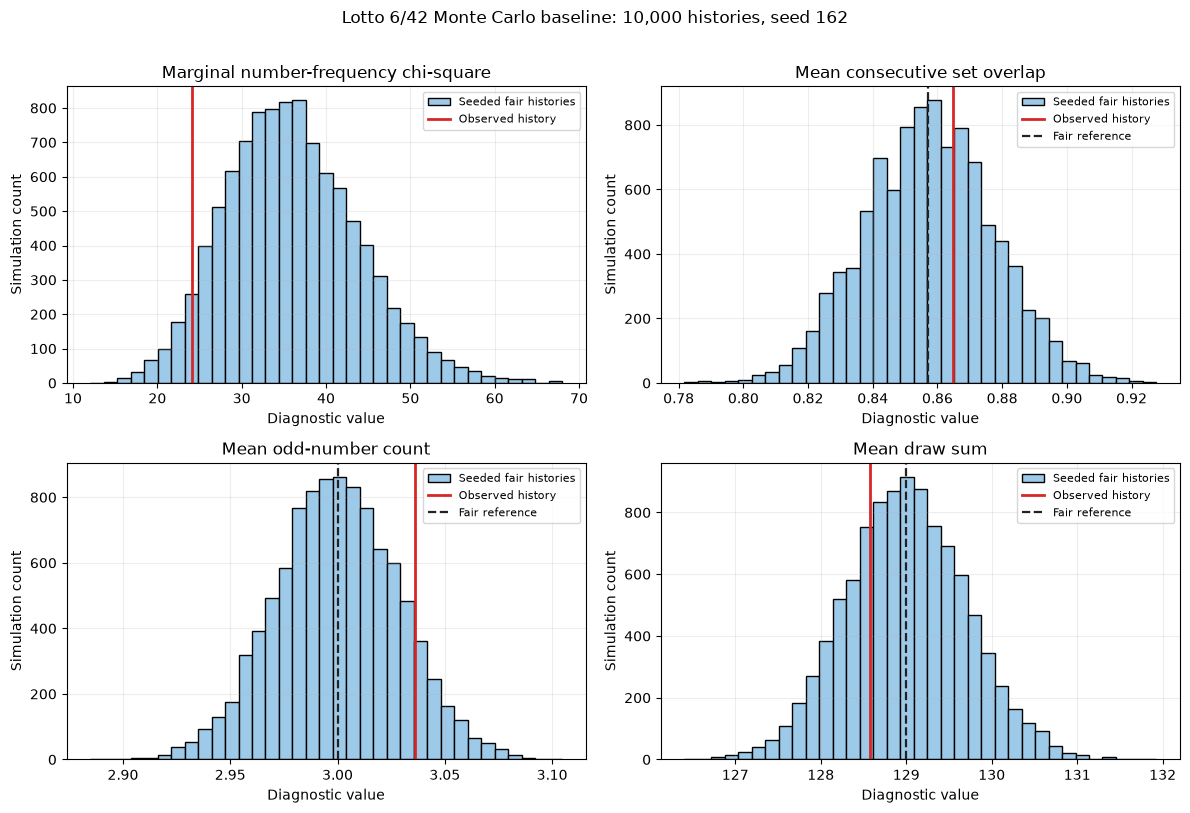

In [13]:
key_diagnostics_6 = [
    ('marginal_number_frequency_chi_square', 'Marginal number-frequency chi-square'),
    ('consecutive_set_overlap_mean', 'Mean consecutive set overlap'),
    ('odd_count_mean', 'Mean odd-number count'),
    ('draw_sum_mean', 'Mean draw sum'),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, label) in zip(axes.flat, key_diagnostics_6):
    values = replayed_values['lotto_6_42'][name]
    observed = diagnostics['lotto_6_42']['diagnostics'][name]['observed_statistic']
    reference = mc.metric_specs('lotto_6_42', len(draws6_mc))[name]['null']
    ax.hist(values, bins=35, color='#9ecae9', edgecolor='black', label='Seeded fair histories')
    ax.axvline(observed, color='#d62728', linewidth=2, label='Observed history')
    if reference is not None:
        ax.axvline(reference, color='#222222', linestyle='--', linewidth=1.6, label='Fair reference')
    ax.set(title=label, xlabel='Diagnostic value', ylabel='Simulation count')
    ax.legend(fontsize=8)
fig.suptitle(f'Lotto 6/42 Monte Carlo baseline: {configuration["initial_simulations_per_game"]:,} histories, seed {configuration["random_seed"]}', y=1.01)
fig.tight_layout()
display(fig)
plt.close(fig)


## 15. Statistical Evidence Summary

**Question:** What is the complete evidence table across the selected Phase 3 diagnostics?
The table uses canonical observed statistics and empirical p-values. For metrics with a numeric theoretical fair reference, that reference is shown. For diagnostics without a scalar null, the random expectation column shows the mean of the seeded simulated distribution. The 3D key-diagnostic histogram panel below is a visual supplement to the table.


In [14]:
evidence_rows = []
for game_name, game_result in diagnostics.items():
    for name, diagnostic in game_result['diagnostics'].items():
        reference = diagnostic['fair_reference']
        if isinstance(reference, (int, float)):
            random_expectation = float(reference)
        else:
            random_expectation = float(diagnostic['initial_simulated_distribution']['mean'])
        evidence_rows.append({
            'Game': game_name,
            'Diagnostic': diagnostic['label'],
            'Observed': diagnostic['observed_statistic'],
            'Random expectation': random_expectation,
            'Empirical p-value': diagnostic['final_empirical_p_value'],
            'Interpretation': diagnostic['interpretation'],
        })
evidence = pd.DataFrame(evidence_rows)
assert list(evidence.columns) == ['Game', 'Diagnostic', 'Observed', 'Random expectation', 'Empirical p-value', 'Interpretation']
display(evidence.round(6))


,Game,Diagnostic,Observed,Random expectation,Empirical p-value,Interpretation
0,3d_lotto,Consecutive multiset-overlap distribution chi-...,0.624615,2.057734,0.736126,consistent_with_fair_random_baseline
1,3d_lotto,Mean consecutive unordered multiset overlap,0.744956,0.742260,0.812819,consistent_with_fair_random_baseline
2,3d_lotto,Digit-sum mean,13.357181,13.500000,0.082292,consistent_with_fair_random_baseline
3,3d_lotto,Digit-sum sample variance,24.575643,24.750000,0.734827,consistent_with_fair_random_baseline
4,3d_lotto,Lag-1 digit-sum correlation,-0.003314,0.000000,0.838616,consistent_with_fair_random_baseline
5,3d_lotto,Maximum absolute digit-share deviation,0.005863,0.005278,0.323368,consistent_with_fair_random_baseline
6,3d_lotto,Pooled digit-frequency chi-square,9.053613,8.954244,0.431157,consistent_with_fair_random_baseline
7,3d_lotto,Repetition-pattern chi-square,1.644173,2.000661,0.444856,consistent_with_fair_random_baseline
8,lotto_6_42,Consecutive set-overlap distribution chi-square,4.024441,3.001010,0.260474,consistent_with_fair_random_baseline
9,lotto_6_42,Mean consecutive-draw set overlap,0.864713,0.857143,0.709329,consistent_with_fair_random_baseline


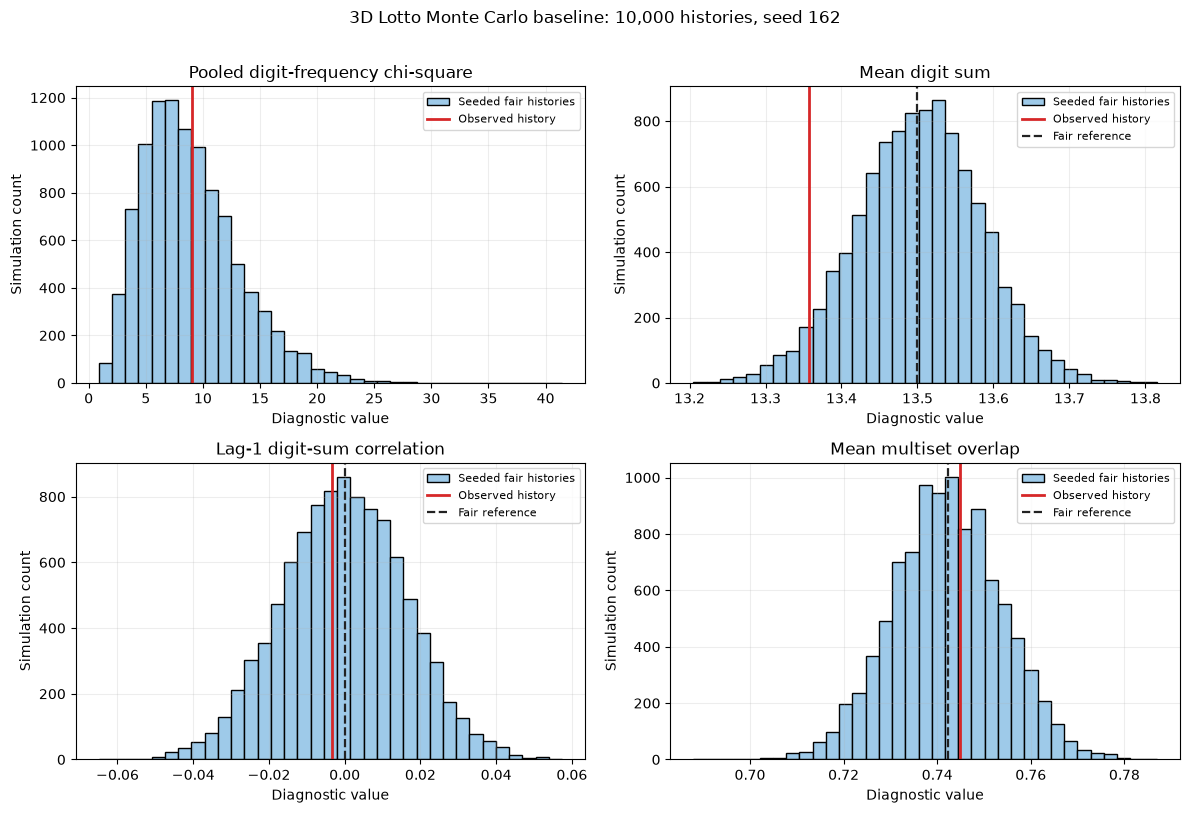

In [15]:
key_diagnostics_3d = [
    ('pooled_digit_frequency_chi_square', 'Pooled digit-frequency chi-square'),
    ('digit_sum_mean', 'Mean digit sum'),
    ('lag1_digit_sum_correlation', 'Lag-1 digit-sum correlation'),
    ('consecutive_multiset_overlap_mean', 'Mean multiset overlap'),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, label) in zip(axes.flat, key_diagnostics_3d):
    values = replayed_values['3d_lotto'][name]
    observed = diagnostics['3d_lotto']['diagnostics'][name]['observed_statistic']
    reference = mc.metric_specs('3d_lotto', len(draws3_mc))[name]['null']
    ax.hist(values, bins=35, color='#9ecae9', edgecolor='black', label='Seeded fair histories')
    ax.axvline(observed, color='#d62728', linewidth=2, label='Observed history')
    if reference is not None:
        ax.axvline(reference, color='#222222', linestyle='--', linewidth=1.6, label='Fair reference')
    ax.set(title=label, xlabel='Diagnostic value', ylabel='Simulation count')
    ax.legend(fontsize=8)
fig.suptitle(f'3D Lotto Monte Carlo baseline: {configuration["initial_simulations_per_game"]:,} histories, seed {configuration["random_seed"]}', y=1.01)
fig.tight_layout()
display(fig)
plt.close(fig)


## 16. Findings and Interpretation

**Finding:** Do the selected diagnostics provide evidence of a departure from the Phase 3 fair-random baseline?
**Evidence:** Count diagnostics crossing p < 0.05 and p < 0.01 directly from the canonical Phase 3 results; report the smallest empirical p-value.
**Interpretation:** A result compatible with the baseline is not proof that the process is perfectly random. A small p-value would motivate investigation, not a claim about which outcome comes next.
**Limitation:** The selected diagnostic family is finite, exploratory, and does not adjust for searching over every possible statistic.


In [16]:
all_diagnostics = [
    (game_name, name, diagnostic)
    for game_name, game_result in diagnostics.items()
    for name, diagnostic in game_result['diagnostics'].items()
]
p_values = [(game, name, float(diagnostic['final_empirical_p_value']), diagnostic['label']) for game, name, diagnostic in all_diagnostics]
minimum_p = min(p_values, key=lambda item: item[2])
count_below_05 = sum(value < 0.05 for _, _, value, _ in p_values)
count_below_01 = sum(value < 0.01 for _, _, value, _ in p_values)
display(Markdown(
    f"**Finding:** {count_below_05} of {len(p_values)} diagnostics have empirical p < 0.05, and {count_below_01} have empirical p < 0.01. "
    f"The smallest empirical p-value is {minimum_p[2]:.6f} for {minimum_p[0]}: {minimum_p[3]}. "
    f"**Interpretation:** The selected statistics are compatible with the simulated fair-random baseline under the Phase 3 decision thresholds. "
    f"**Limitation:** Compatibility is not proof of randomness and is not predictive evidence."
))


**Finding:** 0 of 16 diagnostics have empirical p < 0.05, and 0 have empirical p < 0.01. The smallest empirical p-value is 0.082292 for 3d_lotto: Digit-sum mean. **Interpretation:** The selected statistics are compatible with the simulated fair-random baseline under the Phase 3 decision thresholds. **Limitation:** Compatibility is not proof of randomness and is not predictive evidence.

## 17. Predictive-Signal Readiness

**Status:** Prediction is disabled. No machine-learning model was trained and no number recommendations are made.
The Phase 3 verdict only calibrates selected historical diagnostics against a random baseline. Any future predictive claim would require a separately authorized chronological backtest, out-of-sample evaluation, leakage controls, a prespecified metric, and comparison against a random baseline. Historical frequency does not make a number hot, cold, due, lucky, or more likely.


## 18. JEV Readiness

**Status:** JEV and TypeSafe were not invoked. JEV is inactive in this phase.
Future JEV evidence inputs may include statistical diagnostics, Monte Carlo empirical p-values, effect sizes, temporal stability, model out-of-sample performance, random-baseline performance, and multiple-testing controls. Their collection does not authorize an API call or verdict.


## 19. Limitations

- The analysis depends on the completeness and accuracy of the canonical historical records.
- The fair baseline assumes the stated draw mechanisms: independent decimal digits for 3D and uniform 6-of-42 subsets for Lotto 6/42.
- Ten thousand simulations give finite Monte Carlo resolution; the plus-one empirical p-value cannot be smaller than 1/10,001 for an initial run.
- The selected diagnostics do not cover all possible temporal structure and are not corrected for an unrestricted search over patterns.
- Descriptive differences and statistical significance do not establish predictive value.
- No forecasting, ML, active JEV, or TypeSafe analysis is part of this notebook.


## 20. Conclusion and Next Phase

**Conclusion:** The canonical Phase 2 and Phase 3 inputs validate, the Phase 3 baseline replays exactly, and the recorded verdict is shown from the canonical results artifact.
**Boundary:** Phase 3 evidence may support separately authorized chronological backtest planning. It does not establish predictive signal or authorize Phase 4 execution.
**Safest next action:** Human review this notebook and the Phase 3 evidence, then authorize any Phase 4 planning as a separate task.


In [17]:
canonical_hashes_after = {name: sha256_file(ROOT / name) for name in canonical_read_files}
assert canonical_hashes_after == canonical_hashes_before
assert phase3['phase4_readiness']['status'] == 'READY_FOR_HUMAN_REVIEW_AND_PHASE4_BACKTEST_PLANNING'
assert phase3['verdict'] == 'PHASE3_PASS_RANDOM_COMPATIBLE'
print(f'Canonical files unchanged during notebook execution: {canonical_hashes_after == canonical_hashes_before}')
print(f'Phase 3 verdict: {phase3["verdict"]}')
print(f'Phase 4 readiness boundary: {phase3["phase4_readiness"]["status"]}')
print(f'Prediction enabled: {configuration["prediction_enabled"]}; JEV enabled: {configuration["jev_enabled"]}')
print('100,000-history confirmations run: 0')


Canonical files unchanged during notebook execution: True
Phase 3 verdict: PHASE3_PASS_RANDOM_COMPATIBLE
Phase 4 readiness boundary: READY_FOR_HUMAN_REVIEW_AND_PHASE4_BACKTEST_PLANNING
Prediction enabled: False; JEV enabled: False
100,000-history confirmations run: 0
